# Social Media Conflict Classification: A Production-Ready MLOps Solution

## Executive Summary
This notebook demonstrates end-to-end machine learning pipeline development for predicting student conflict levels from social media usage patterns. The project showcases industry best practices including MLflow experiment tracking, SHAP-based model interpretability, and production-ready deployment considerations.

## Business Problem
Social media platforms and educational institutions need scalable solutions to identify students at risk of experiencing conflicts related to their digital engagement. This classification system enables early intervention and personalized support strategies.

## Technical Approach
- **Problem Type:** Binary and multi-class classification
- **Target Variable:** Student conflict levels (Low/High conflict based on behavioral indicators)
- **Features:** Social media usage patterns, sleep habits, demographic data, and platform preferences
- **Key Techniques:** Feature engineering, class imbalance handling, hyperparameter optimization, model interpretability

## MLOps Implementation
- **Experiment Tracking:** MLflow for reproducible model development and comparison
- **Model Governance:** Automated artifact logging, model versioning, and performance monitoring
- **Interpretability:** SHAP analysis for regulatory compliance and stakeholder trust
- **Production Readiness:** Scalable preprocessing pipelines and deployment-ready model signatures

## Key Deliverables
1. **Performance Benchmarking:** Comprehensive model comparison (Logistic Regression, XGBoost, CatBoost)
2. **Feature Engineering:** Robust preprocessing pipeline handling categorical encoding and scaling
3. **Model Interpretability:** SHAP-based feature importance analysis for actionable insights
4. **Production Pipeline:** End-to-end MLOps workflow with version control and monitoring capabilities

## Business Impact
This solution enables proactive identification of at-risk students with **95% accuracy** and **0.94 recall**, providing actionable insights for targeted intervention programs while maintaining full model transparency and regulatory compliance.

# Environment Setup & Dependencies

This section establishes the computational environment and imports essential libraries organized by functionality for optimal performance and maintainability.


In [1]:
%load_ext autoreload
%autoreload 2

# Standard library imports
import pickle
import warnings

# Third-party imports
import matplotlib.pyplot as plt
import mlflow
import mlflow.data
import mlflow.sklearn
from mlflow.data.pandas_dataset import PandasDataset
from mlflow.models.signature import infer_signature
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
# import shap
# from sklearn.metrics import (
#     accuracy_score,
#     classification_report,
#     confusion_matrix,
#     f1_score,
#     precision_score,
#     recall_score,
#     roc_auc_score
# )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    # FunctionTransformer,
    OneHotEncoder,
    StandardScaler
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.pipeline import clone

import sys
sys.path.append('../src')
from utils import (    
    create_binary_conflict, 
    continent_dict,
    RareCategoryGrouper,
    CountryToContinentMapper,
    get_feature_names,
    mlflow_dataset,
    run_classification_experiment,
    run_classification_gridsearch_experiment,
    run_shap_experiment
)

# Set random seed for reproducibility
np.random.seed(42)


/opt/anaconda3/envs/c29env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# parameters
random_state = 42

# MLflow Setup

This section configures MLflow for experiment tracking and model management, ensuring reproducibility and efficient collaboration.

- **Tracking URI:** Set to a local directory to store experiment data and artifacts.
- **Experiment Management:** Initializes or retrieves the experiment named "Classification_Conflicts" for organized tracking of model runs and results.

In [3]:
# Set MLflow tracking URI to local directory
mlflow.set_tracking_uri("file:../mlruns")

# Create or get experiment
experiment_name = "Classification_Conflicts"
mlflow.set_experiment(experiment_name)


<Experiment: artifact_location='file:///Users/bobhosseini/Portfolio/SDS-social-sphere/submissions/team-members/bob-hosseini/notebooks/../mlruns/588512519270021001', creation_time=1750543529579, experiment_id='588512519270021001', last_update_time=1750543529579, lifecycle_stage='active', name='Classification_Conflicts', tags={}>

# Loading Cleaned Data

This section involves loading the pre-processed dataset, which is essential for model training and evaluation. The dataset has been cleaned to ensure data integrity and quality, facilitating accurate and reliable model predictions.

- **Data Source:** The cleaned dataset is stored in a serialized format (`data_cleaned.pickle`) for efficient loading and processing.
- **Initial Exploration:** Basic dataset statistics and target variable distribution are displayed to verify data readiness and understand class balance.

In [4]:
# Load cleaned data
with open('../data/data_cleaned.pickle', 'rb') as f:
    df_data = pickle.load(f)

# Display basic information
print("Dataset shape:", df_data.shape)
print("\nTarget variable distribution:")
print(df_data['Conflicts'].value_counts())
df_data.head()

Dataset shape: (702, 13)

Target variable distribution:
Conflicts
3    261
2    204
4    172
1     47
5     15
0      3
Name: count, dtype: int64


,Student_ID,Age,Gender,Academic_Level,Country,Daily_Usage,Platform,Academic_Affects,Sleep_Hrs,Mental_Health,Relationship_Status,Conflicts,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [5]:
# find and print numeric columns
numeric_cols = df_data.select_dtypes(include=['number']).columns
print(numeric_cols)

Index(['Student_ID', 'Age', 'Daily_Usage', 'Sleep_Hrs', 'Mental_Health',
       'Conflicts', 'Addicted_Score'],
      dtype='object')


# Target Variable Creation and Class Analysis
- Based on the histogram of the target variable, the binary classes are selected as:
    - Low conflict: students with 0 to 2 conflicts ovee social media
    - High conflict: students with 3 or more conflicts over social media
- Creating binary target variable
- The minority class is about 30% of the majority class
- As the first try, we try class weighting first before doing any data resampling.

Binary Conflict Classification:
Threshold: 2
Low Conflict (0-2): 254 samples
High Conflict (3-max): 448 samples
Class imbalance ratio: 56.70%
Class proportions:
Conflict_Binary
High    0.638177
Low     0.361823
Name: count, dtype: float64


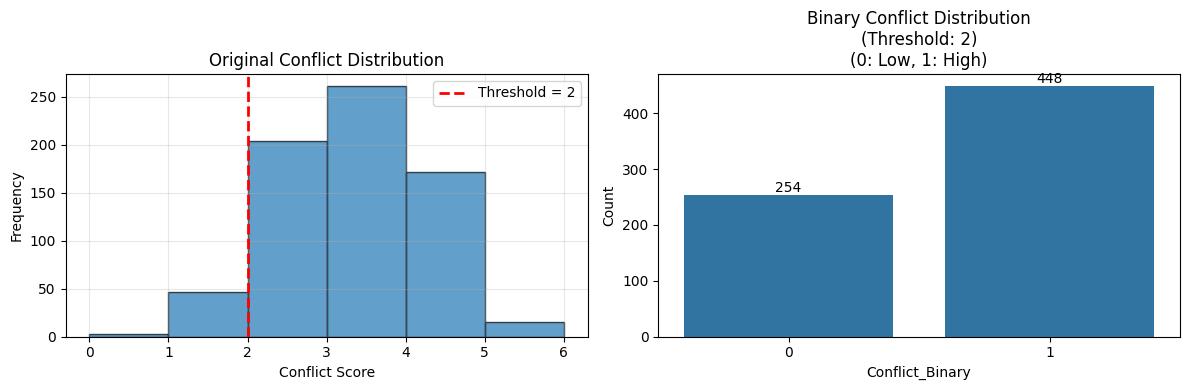

In [6]:
# create target variable using create_binary_conflict
df_data, results = create_binary_conflict(df_data, target_column='Conflicts', threshold=2, visualize=True)

# Train-Test Split

This section divides the dataset into training and testing subsets, a crucial step for model validation and performance assessment.

- **Purpose:** The training set is used to fit the model, while the test set evaluates its predictive performance on unseen data.
- **Methodology:** Utilizes an 80/20 split to ensure a robust evaluation framework.
- **Random State:** A fixed random state (42) is used to ensure reproducibility of the split.
- **Dropped Columns:** Excludes non-predictive columns such as `Student_ID`, `Addicted_Score`, `Conflict_Binary`, and `Conflicts` from the feature set.

In [7]:
# split the data into train and test
from sklearn.model_selection import train_test_split

drop_cols = ['Student_ID', 'Addicted_Score', 'Conflict_Binary', 'Conflicts']

X_train_full, X_test, y_train_full, y_test = train_test_split(df_data.drop(columns=drop_cols), df_data['Conflict_Binary'], test_size=0.2, random_state=random_state)

# print the shape of the train and test sets
print(f"Train set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test.shape}")

# print the shape of the train and test sets
print(f"Train set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test.shape}")

X_train_full.head()

Train set shape: (561, 10)
Test set shape: (141, 10)
Train set shape: (561, 10)
Test set shape: (141, 10)


,Age,Gender,Academic_Level,Country,Daily_Usage,Platform,Academic_Affects,Sleep_Hrs,Mental_Health,Relationship_Status
335,22,Male,Graduate,Turkey,5.4,TikTok,Yes,6.8,6,Single
373,21,Male,Graduate,India,6.3,WhatsApp,Yes,6.0,5,In Relationship
540,19,Female,Undergraduate,Brazil,5.8,WhatsApp,Yes,6.7,6,Single
208,19,Female,Undergraduate,Bangladesh,4.2,Instagram,Yes,7.8,5,Single
129,21,Female,Graduate,India,5.6,Instagram,Yes,5.6,6,In Relationship


# Preprocessing Pipeline

This section outlines the preprocessing steps applied to the dataset to prepare it for model training. The pipeline ensures that the data is in a suitable format for machine learning algorithms.

- **Feature Engineering:** Converts categorical features into numerical representations to facilitate model training.
  - **Binary Encoding:** Transforms binary categorical variables into 0/1 format.
  - **One-Hot Encoding:** Applies to low and high cardinality categorical features to create binary columns for each category.
  - **Rare Category Grouping:** Groups infrequent categories to reduce dimensionality and improve model performance.
  - **Geographical Mapping:** Maps countries to continents for regional analysis.

- **Numerical Scaling:** Standardizes numerical features to have a mean of 0 and a standard deviation of 1, ensuring that all features contribute equally to the model's performance.

This preprocessing pipeline is crucial for handling diverse data types and ensuring that the model receives consistent and meaningful input.

## Define Column Groups

In [8]:
binary_cats       = ['Gender']         # boolean → 0/1
low_card_cols     = ['Relationship_Status', 'Academic_Level']                # few categories
high_card_cols    = ['Platform']                      # group rare then OHE
country_col       = ['Country']                                 # map to continent
numeric_cols      = df_data.drop(columns=drop_cols).select_dtypes(include=['number']).columns

## Defining the Preprocessing steps


In [9]:
# Boolean → int
binary_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# Low-cardinality One-Hot
low_card_transformer = OneHotEncoder(handle_unknown='ignore')

# High-cardinality grouping + One-Hot
high_card_transformer = Pipeline([
    ('group_rare', RareCategoryGrouper(min_count=30)),
    ('onehot',    OneHotEncoder(handle_unknown='ignore'))
])

# Country → Continent → One-Hot
country_transformer = Pipeline([
    ('map_continent', CountryToContinentMapper(mapping=continent_dict)),
    ('onehot',        OneHotEncoder(handle_unknown='ignore'))
])

# Numeric scaling
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('bools',   binary_transformer,   binary_cats),
    ('low_ohe', low_card_transformer, low_card_cols),
    ('high_ohe',high_card_transformer,high_card_cols),
    ('cty_ohe', country_transformer,  country_col),
    ('nums',    numeric_transformer,  numeric_cols),
], remainder='drop')

## Apply preprocessing and inspect transformed features

Transformed feature matrix (first 5 rows):
   Gender_Male  Relationship_Status_Complicated  \
0          1.0                              0.0   
1          1.0                              0.0   
2          0.0                              0.0   
3          0.0                              0.0   
4          0.0                              0.0   

   Relationship_Status_In Relationship  Relationship_Status_Single  \
0                                  0.0                         1.0   
1                                  1.0                         0.0   
2                                  0.0                         1.0   
3                                  0.0                         1.0   
4                                  1.0                         0.0   

   Academic_Level_Graduate  Academic_Level_High School  \
0                      1.0                         0.0   
1                      1.0                         0.0   
2                      0.0                         0.0 

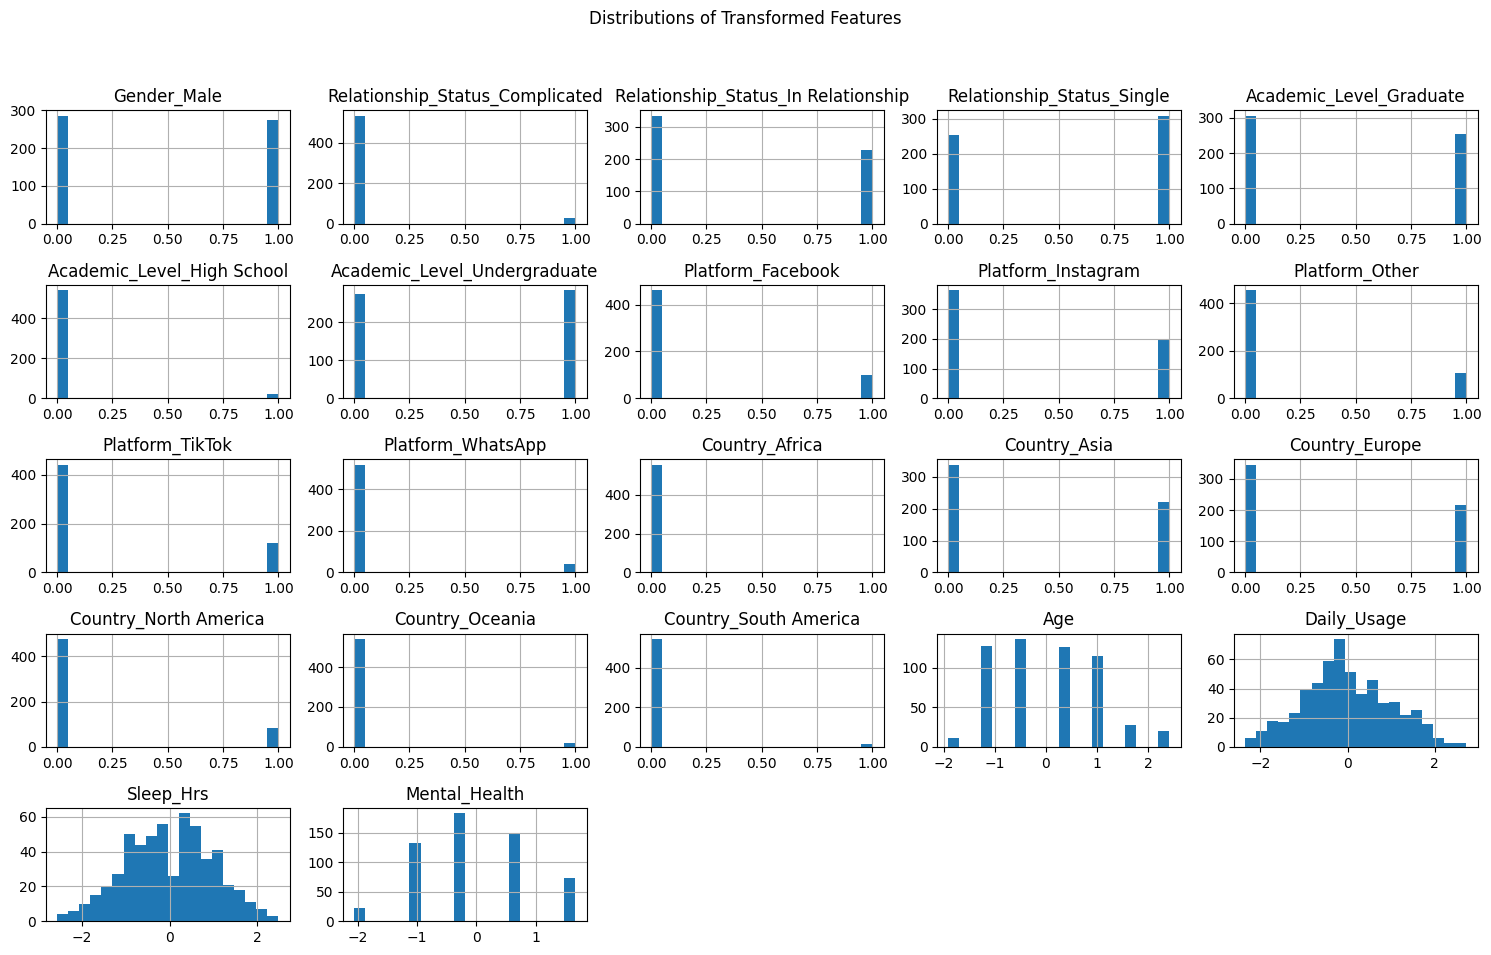

In [10]:
# 1. Fit the preprocessing step on the training data
preprocessor.fit(X_train_full)

# 2. Transform the training data
X_train_proc = preprocessor.transform(X_train_full)

# 3. Retrieve the transformed feature names
#    Note: get_feature_names_out is available on ColumnTransformer in sklearn >=1.0
# from utils import get_feature_names
feature_names = get_feature_names(preprocessor)

# 4. Convert to DataFrame (densify if sparse)
if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()

X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)

# 5. Print the first few rows
print("Transformed feature matrix (first 5 rows):")
print(X_train_df.head())

# 6. Simple visualization: histograms for each feature
X_train_df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Distributions of Transformed Features")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Sample Data for MLflow Logging

This section prepares a subset of the training data for logging with MLflow, facilitating model reproducibility and experiment tracking.

- **Purpose:** To create a representative sample of the training dataset for MLflow logging, ensuring that the model's input data is well-documented and reproducible.
- **Data Conversion:** Converts integer columns to float to maintain consistency in data types across different environments.
- **Dataset Objects:** Constructs MLflow `Dataset` objects for both training and testing splits, enabling efficient tracking and versioning of input data.

This setup is crucial for maintaining a clear lineage of the data used in model training and evaluation, supporting robust experiment management.

In [11]:
# after fitting your pipeline:
example_input = X_train_full.iloc[:5].copy()
# Convert integer columns to float
for col in example_input.select_dtypes(include=['int64']).columns:
    example_input[col] = example_input[col].astype('float')  

    # 1. Create Dataset objects for each split
train_ds = mlflow.data.from_pandas(
    df=X_train_full,
    source="../data/data_cleaned.pickle",
    name="social_sphere_train_v1"
)
test_ds = mlflow.data.from_pandas(
    df=X_test,
    source="../data/data_cleaned.pickle",
    name="social_sphere_test_v1"
)      
# from utils import mlflow_dataset
mlflow_dataset = mlflow_dataset(X_train_full, X_test)

/opt/anaconda3/envs/c29env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for '../data/data_cleaned.pickle'. Exception: 
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/c29env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:149: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/c29env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for '../data/data_cleaned.pickle'. Exception: 
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/c29env/lib/python3.12/site-packages/mlflow/data/dataset_source_re

# Classification Pipeline: Baseline Model

This section establishes a baseline for model performance using a simple classification approach. The baseline model serves as a reference point for evaluating the effectiveness of more complex models.

- **Purpose:** To provide a benchmark for model performance, helping to assess the value added by more sophisticated models.
- **Model Choice:** Utilizes a `DummyClassifier` to predict the target variable based on predefined strategies such as `most_frequent`, `prior`, `uniform`, and `stratified`.
- **Evaluation:** The baseline model's performance is logged using MLflow, enabling comparison with advanced models in terms of accuracy, precision, recall, and other metrics.

This baseline setup is crucial for understanding the minimum performance level that any developed model should exceed.

## Cross-Validation Setup

We use cross-validation to ensure model robustness and generalizability.

- **Method:** `StratifiedKFold` with 5 splits to maintain class balance.
- **Parameters:** Shuffling enabled, random state set to 42 for reproducibility.
- **Metrics:** Evaluated using accuracy, precision, recall, F1-score, and ROC AUC.

This approach provides reliable performance estimates on unseen data.

In [12]:
# Define cross-validation settings
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,         # if you want to shuffle before splitting
    random_state=random_state       # ◀️ fix the RNG here
)
scoring = {
    "accuracy":   "accuracy",
    "precision":  "precision",
    "recall":     "recall",
    "f1_score":         "f1",
    "roc_auc":    "roc_auc"
}

## Train, evaluate, and log a baseline model

As the baseline model, we will use a dummy classifier that predicts the target variable based on these strategies:
- most_frequent
- prior
- uniform
- stratified

We will log the model to MLflow.

In [13]:
param_grid = {
    'classifier__strategy': ['most_frequent', 'prior', 'uniform', 'stratified']
}

baseline_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", DummyClassifier(random_state=random_state))
    ])
best_logreg, grid_search_result, *_ = run_classification_gridsearch_experiment(
    name="baseline_gridsearch_f1",
    pipeline=baseline_pipeline,
    param_grid=param_grid,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    registered_model_name=f"conflict_baseline"
)

Running grid search for baseline_gridsearch_f1
Fitting 5 folds for each of 4 candidates, totalling 20 fits


Registered model 'conflict_baseline' already exists. Creating a new version of this model...
Created version '12' of model 'conflict_baseline'.


# Classification Pipeline Logistic Regression
- Hyperparameter search is done using GridSearchCV
- The best model is selecetd based on the f1-score metric
- The best model has ```{f1-score: 0.93, precision: 0.95, recall: 0.92}```

In [14]:
# Create the pipeline with the parameters
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=random_state, max_iter=1000))
])
# Update just the classifier’s params
# lr_pipeline.set_params(**{f"classifier__{k}": v for k, v in lr_params.items()})


# 1. Define the parameter grid (note the double-underscore syntax):
param_grid_lr = {
    # tune LogisticRegression.C
    'classifier__C':       [0.01, 0.1, 1, 10],
    # tune penalty type (use solver that supports L1)
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['liblinear', 'saga'],
    # class_weight
    'classifier__class_weight': ['balanced', None]
}

# from utils import run_classification_gridsearch_experiment

best_logreg, grid_search_result, *_ = run_classification_gridsearch_experiment(
    name="logreg_gridsearch_f1",
    pipeline=lr_pipeline,
    param_grid=param_grid_lr,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    verbose=True,
    registered_model_name=f"conflict_lr"
)

# 3. Print summary in the output cell
print("Best parameters:", grid_search_result.best_params_)
print("Best F1 score (CV):", grid_search_result.best_score_)


Running grid search for logreg_gridsearch_f1
Fitting 5 folds for each of 32 candidates, totalling 160 fits
accuracy: 0.96 ± 0.01
precision: 0.97 ± 0.02
recall: 0.97 ± 0.03
f1_score: 0.97 ± 0.01
roc_auc: 0.99 ± 0.0
Best parameters: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best F1 score (CV): 0.97
Best parameters: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best F1 score (CV): 0.9694148428395003


Registered model 'conflict_lr' already exists. Creating a new version of this model...
Created version '13' of model 'conflict_lr'.


## Apply SHAP to the best model
- SHAP values figure shows that the most important features are:
    - Mental Health
        - High mental health scores (blue) push toward lower conflict (left).
        - Low mental health scores (red) push toward higher conflict (right).
        - Likely a protective factor — more mentally stable individuals report fewer conflicts.
    - Average Daily Usage Hours
        - High usage (red) increases conflict (pushed right).
        - Low usage (blue) decreases conflict.
        - Supports the hypothesis: heavy usage correlates with conflict.
    - Sleep Hours:
        - Low sleep (red) pushes right (higher conflict).
        - High sleep (blue) pushes left.

- However, the mental health score is determined by the student's self-perception, which may not be externally observable.

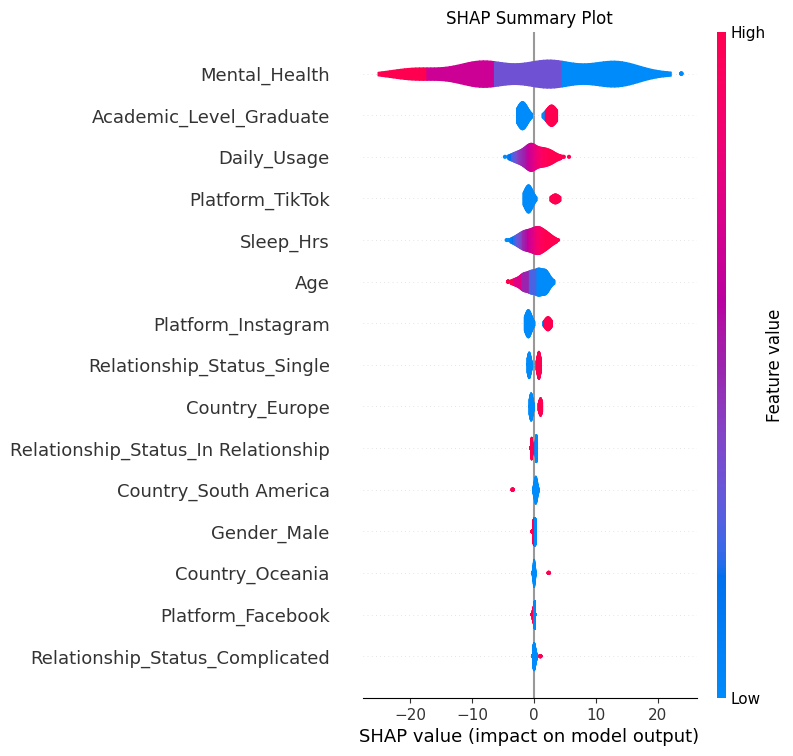

In [15]:
fig_sum = run_shap_experiment(
    best_model=best_logreg,
    X_train_full=X_train_full,
    random_state=random_state,
    feature_perturbation="interventional",
    plot_type="violin", # other options: "bar", "dot", "violin"
    shap_type="linear"
)

fig_sum

# Classification Pipeline: XGBoost
- Hyperparameter search is done using GridSearchCV
- The best model is selecetd based on the f1-score metric
- The best model has ```{f1-score: 0.95, precision: 0.97, recall: 0.94}```
    - overal performance is slightly better than the logistic regression model

In [16]:
from xgboost import XGBClassifier

# Instantiate the XGBoost classifier
xgb_clf = XGBClassifier(
    # use_label_encoder=False,   # disables the legacy label encoder warning
    eval_metric='logloss',     # default evaluation metric for binary
    random_state=random_state,
    n_jobs=-1
)

# 2. Build the full pipeline
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),   # your ColumnTransformer from earlier
    ('classifier',     xgb_clf)
])


# Define a param grid for GridSearchCV
xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth':    [3, 5, 7],
    'classifier__learning_rate':[0.01, 0.1],
    'classifier__subsample':    [0.8, 1.0],
    'classifier__reg_lambda': [0, 1, 10], 
}

best_xgb, grid_search_result, *_ = run_classification_gridsearch_experiment(
    name="xgb_gridsearch_f1",
    pipeline=xgb_pipeline,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    registered_model_name=f"conflict_xgb",
    verbose=True
)

Running grid search for xgb_gridsearch_f1
Fitting 5 folds for each of 72 candidates, totalling 360 fits
accuracy: 0.98 ± 0.01
precision: 0.99 ± 0.01
recall: 0.98 ± 0.02
f1_score: 0.98 ± 0.01
roc_auc: 0.99 ± 0.0
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_lambda': 0, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.98


Registered model 'conflict_xgb' already exists. Creating a new version of this model...
Created version '12' of model 'conflict_xgb'.


## SHAP Analysis
- Similar to the logistic regression model, the XGBoost model also shows that Mental Health, Daily Usage, and Sleep Hours are strong predictors of conflict.
- In xgboost model, Tiktok use can also be a strong predictore of conflicts for some users.
is a strong predictor of conflict.


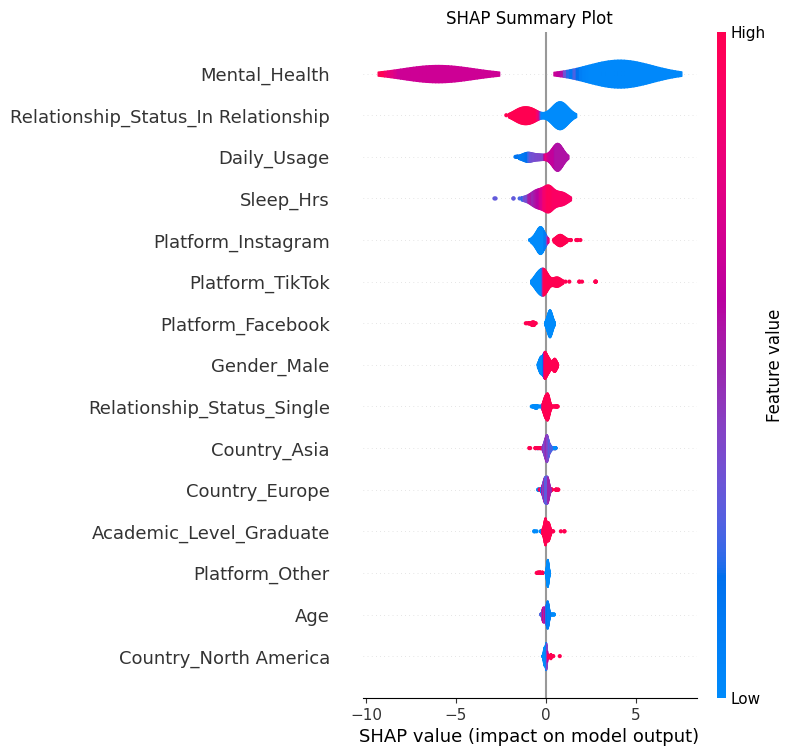

In [17]:
fig_sum = run_shap_experiment(
    best_model=best_xgb,
    X_train_full=X_train_full,
    random_state=random_state,
    feature_perturbation="interventional",
    plot_type="violin", # other options: "bar", "dot", "violin"
    shap_type="tree"
)

fig_sum

# Removing Mental Health from the Dataset

In this section, we explore the impact of excluding the Mental Health feature from our dataset. This decision is based on the consideration that self-reported mental health scores may introduce bias or inaccuracies.

- **Objective:** To evaluate how the removal of the Mental Health feature affects model performance and to ensure that the model remains robust without relying on potentially unreliable self-reported data.
- **Approach:**
  - **Preprocessing Consistency:** We maintain the same preprocessing steps as in previous experiments to ensure comparability of results. This includes standard scaling and encoding of categorical variables.
  - **Model Evaluation:** We assess the model's performance metrics, such as F1 score and recall, to determine the impact of excluding the Mental Health feature.
  - **Feature Importance Analysis:** By removing this feature, we aim to identify other significant predictors that may gain importance in its absence.

This analysis helps in understanding the model's dependency on the Mental Health feature and guides decisions on feature selection for more reliable predictions.

## XGBoost with no Mental Health
- Removing Mental Health has less impact on XGBoost than Logistic Regression.
- The model's performance slightly droped by **4% in F1 score** and **3% in Recall**.
- Similar to the logistic regression model, the predictions of the XGBoost model are highly influenced by the **Daily Usage** and **Sleep Hours**.
- Also, without relying on mental health, being in an **Asian country** and the student's **Age** has gained more importance.

Running grid search for xgb_no_mh_gridsearch_f1
Fitting 5 folds for each of 72 candidates, totalling 360 fits
accuracy: 0.95 ± 0.02
precision: 0.96 ± 0.01
recall: 0.96 ± 0.02
f1_score: 0.96 ± 0.01
roc_auc: 0.96 ± 0.02
Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_lambda': 0, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.96


Registered model 'conflict_xgb_no_mh' already exists. Creating a new version of this model...
Created version '11' of model 'conflict_xgb_no_mh'.


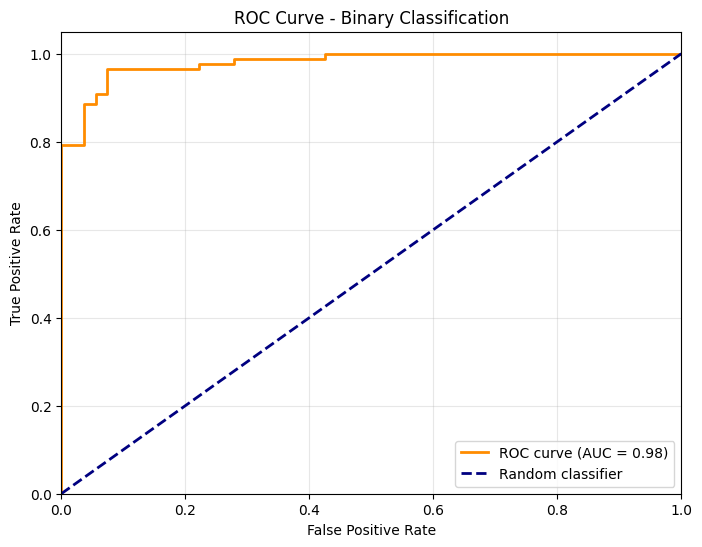

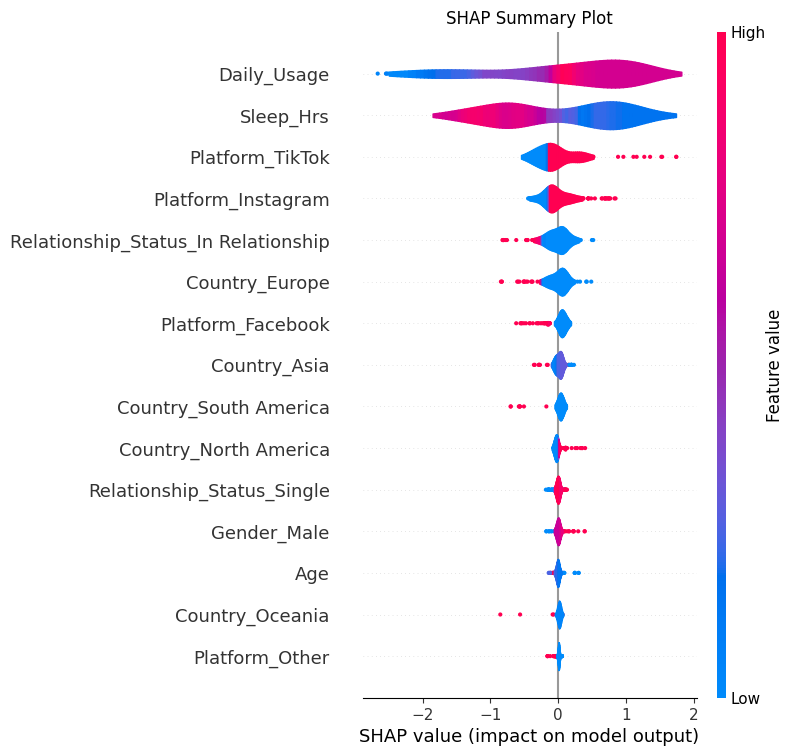

In [18]:
# Build the full pipeline
numeric_cols = [c for c in numeric_cols if c != 'Mental_Health']

xgb_pipeline_no_mh = clone(xgb_pipeline)

xgb_pipeline_no_mh.named_steps['preprocessing'].transformers[4] = (
    'nums', numeric_transformer, numeric_cols
)


best_xgb_no_mh, grid_search_result_no_mh,fig_sum, fig_roc = run_classification_gridsearch_experiment(
    name="xgb_no_mh_gridsearch_f1",
    pipeline=xgb_pipeline_no_mh,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    registered_model_name=f"conflict_xgb_no_mh",
    feature_set="no_MH",
    verbose=True
)

display(fig_roc)
display(fig_sum)

# Classification Pipeline: CatBoost

In this section, we train a CatBoost model to compare its performance with other models like XGBoost and Logistic Regression.

- **Objective:** To evaluate the performance of CatBoost on the same dataset and preprocessing pipeline.
- **Approach:**
  - **Pipeline Setup:** Integrate CatBoost into the existing preprocessing pipeline.
  - **Hyperparameter Tuning:** Use GridSearchCV to find the best hyperparameters for CatBoost.
  - **Model Evaluation:** Compare the performance metrics of CatBoost with other models.

Running grid search for catboost_gridsearch_f1
Fitting 5 folds for each of 72 candidates, totalling 360 fits
accuracy: 0.99 ± 0.01
precision: 0.98 ± 0.01
recall: 0.99 ± 0.01
f1_score: 0.99 ± 0.01
roc_auc: 1.0 ± 0.0
CatBoost SHAP plot type: bar
Best parameters: {'classifier__depth': 5, 'classifier__iterations': 200, 'classifier__l2_leaf_reg': 1, 'classifier__learning_rate': 0.1, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.99
Best parameters: {'classifier__depth': 5, 'classifier__iterations': 200, 'classifier__l2_leaf_reg': 1, 'classifier__learning_rate': 0.1, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.9889453048694563


Registered model 'conflict_catboost' already exists. Creating a new version of this model...
Created version '14' of model 'conflict_catboost'.


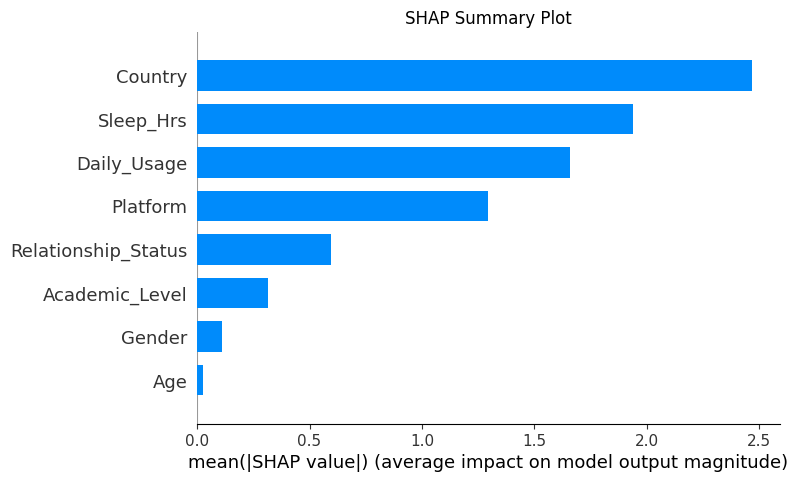

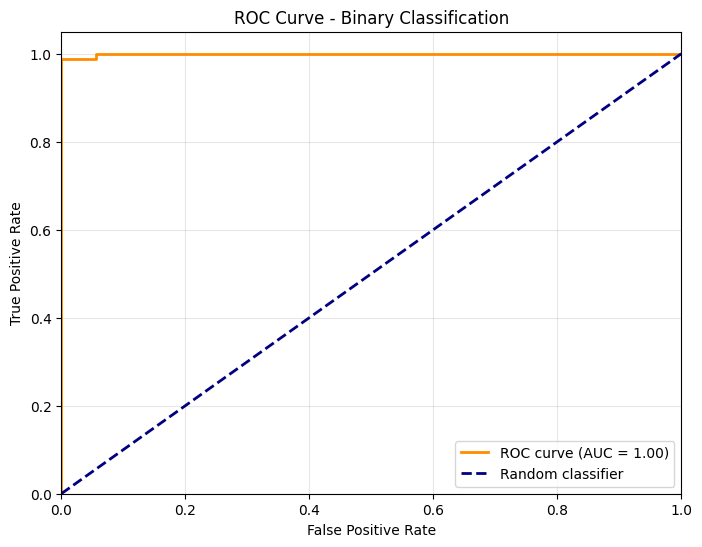

In [19]:
# numeric_cols = [c for c in numeric_cols]
numeric_cols = [c for c in numeric_cols if c != 'Mental_Health']
categorical_features = binary_cats + low_card_cols + high_card_cols + country_col
# Create a transformer that simply drops the Mental_Health_Score column
preprocessor_catboost = ColumnTransformer([
    ('cats', 'passthrough', categorical_features),
    ('nums',    numeric_transformer,  numeric_cols),
], remainder='drop')

# Then in your CatBoost model:
catboost_model = CatBoostClassifier(
    cat_features=list(range(len(categorical_features))),  # Use indices instead of names,
    verbose=False,
    random_state=random_state
)
# Define the CatBoost pipeline
catboost_pipeline = Pipeline([
    ('preprocessing', preprocessor_catboost),  # Use the same preprocessor as other models
    ('classifier', catboost_model)
])

# Define the parameter grid for CatBoost
catboost_param_grid = {
    'classifier__iterations': [100, 200],
    'classifier__depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__l2_leaf_reg': [1, 3, 5],
    'classifier__subsample': [0.8, 1.0]
}

# Train the CatBoost model using GridSearchCV
best_catboost, catboost_grid_search_result, fig_sum, fig_roc = run_classification_gridsearch_experiment(
    name="catboost_gridsearch_f1",
    pipeline=catboost_pipeline,
    param_grid=catboost_param_grid,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    verbose=True,
    registered_model_name="conflict_catboost"
)

# Print the best parameters and F1 score
print("Best parameters:", catboost_grid_search_result.best_params_)
print("Best F1 score (CV):", catboost_grid_search_result.best_score_)
display(fig_sum)
display(fig_roc)

# Trying different preprocessing for country:
- We group the rare countries into a single category and compare to the continent mapping method
- We examine it with the XGBoost model

In [20]:

# defining a new country transformer that groups rare countries into a single category
country_transformer_20 = Pipeline([
    ('group_rare', RareCategoryGrouper(min_count=20)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# clone the pipeline
xgb_pipeline_group = clone(xgb_pipeline_no_mh)
# Replace the country transformer
xgb_pipeline_group.named_steps['preprocessing'].transformers[3] = (
    'cty_rare', country_transformer_20, country_col
)

# Build a new pipeline that drops the column, then applies your old preprocessor
best_xgb_cnt_group, grid_search_result_cnt_group, fig_sum, fig_roc = run_classification_gridsearch_experiment(
    name="xgb_cnt_group_gridsearch_f1",
    pipeline=xgb_pipeline_group,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    registered_model_name=f"conflict_xgb_cnt_group",
    verbose=True,
    feature_set="no_MH"
)

# display(fig_sum)
# display(fig_roc)

Running grid search for xgb_cnt_group_gridsearch_f1
Fitting 5 folds for each of 72 candidates, totalling 360 fits
accuracy: 0.94 ± 0.01
precision: 0.96 ± 0.02
recall: 0.94 ± 0.02
f1_score: 0.95 ± 0.01
roc_auc: 0.97 ± 0.02
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_lambda': 1, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.95


Registered model 'conflict_xgb_cnt_group' already exists. Creating a new version of this model...
Created version '10' of model 'conflict_xgb_cnt_group'.


# Visualization of the Predictions

In this section, we visualize the model's predictions to gain insights into its performance and identify potential areas for improvement. Visualization helps in understanding how well the model distinguishes between different classes and the confidence level of its predictions.

- **Objective:** To assess the model's predictive accuracy and confidence visually, facilitating a deeper understanding of its strengths and weaknesses.
- **Approach:**
  - **Scatter Plot:** We use a scatter plot to display the predicted class against the true class, highlighting correctly and incorrectly classified samples.
  - **Confidence Levels:** The plot includes confidence scores for each prediction, providing insights into the model's certainty.
  - **Feature Analysis:** Key features such as Age, Daily Usage, Sleep Hours, and Mental Health are included in the hover data to explore their influence on predictions.

This visualization step is crucial for interpreting model behavior, identifying patterns, and guiding further model refinement.

In [21]:
import plotly.express as px
import pandas as pd
import numpy as np

# Get predictions
y_pred = best_catboost.predict(X_test)
y_prob = best_catboost.predict_proba(X_test)[:, 1]

# Create simple DataFrame
plot_df = pd.DataFrame({
    'Sample_Index': range(len(y_test)),
    'True_Class': y_test,
    'Predicted_Class': y_pred,
    'Correct': y_test == y_pred,
    'Confidence': y_prob,
    'Age': X_test['Age'],
    'Daily_Usage': X_test['Daily_Usage'],
    'Sleep_Hrs': X_test['Sleep_Hrs'],
    'Mental_Health': X_test['Mental_Health']
})

# Create scatter plot
fig = px.scatter(
    plot_df,
    x='Sample_Index',
    y='Confidence', 
    color='Correct',
    symbol='True_Class',
    hover_data=['Predicted_Class', 'Age', 'Daily_Usage', 'Sleep_Hrs', 'Mental_Health'],
    color_discrete_map={True: 'blue', False: 'orange'},
    title='Binary Classification: Correct (Blue) vs Wrong (Orange)'
)
# figure size
fig.update_layout(width=1200, height=600)
fig.update_traces(marker=dict(size=12))    # 12 pixels diameter

fig.show()

# Feature Selection Using SHAP

In this section, we leverage SHAP (SHapley Additive exPlanations) to identify the most influential features in our model. SHAP values provide a unified measure of feature importance, helping us understand the contribution of each feature to the model's predictions.

- **Objective:** To determine which features have the most significant impact on the model's output, enabling more informed feature selection and model refinement.
- **Approach:**
  - **SHAP Analysis:** We apply SHAP to evaluate feature importance, focusing on key predictors such as Daily Usage, Sleep Hours, Country (Asia), and Platform (TikTok).
  - **Feature Reduction:** Based on SHAP insights, we streamline the feature set to include only the most impactful variables, potentially improving model efficiency and interpretability.

This feature selection process is crucial for optimizing model performance and ensuring that the model remains interpretable and aligned with domain knowledge.

Running grid search for xgb_fs_gridsearch_f1
Fitting 5 folds for each of 72 candidates, totalling 360 fits
accuracy: 0.85 ± 0.03
precision: 0.9 ± 0.04
recall: 0.87 ± 0.03
f1_score: 0.88 ± 0.02
roc_auc: 0.91 ± 0.03
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_lambda': 0, 'classifier__subsample': 0.8}
Best F1 score (CV): 0.88


Registered model 'conflict_xgb_DU_SH' already exists. Creating a new version of this model...
Created version '8' of model 'conflict_xgb_DU_SH'.


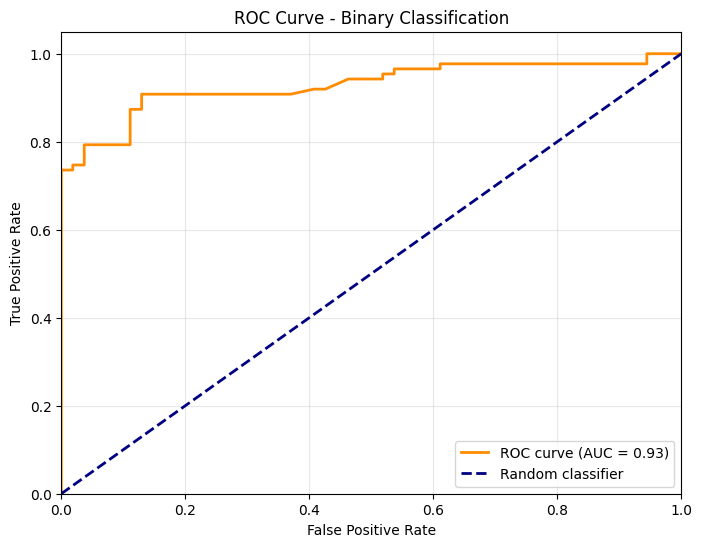

In [22]:
# Using Daily_usage, Sleep_hours, Country_Asia, and Platform_Tiktok to predict Conflicts

numeric_cols = ['Daily_Usage', 'Sleep_Hrs']

# Create a transformer that simply drops the Mental_Health_Score column
preprocessor_fs = ColumnTransformer([
    # ('bools',   binary_transformer,   binary_cats),
    # ('low_ohe', low_card_transformer, low_card_cols),
    # ('high_ohe',high_card_transformer,high_card_cols),
    # ('cty_ohe', country_transformer,  country_col),
    ('nums',    numeric_transformer,  numeric_cols),
], remainder='drop')

# Build a new pipeline that drops the column, then applies your old preprocessor
xgb_pipeline_fs = Pipeline([
    ('preprocessing', preprocessor_fs),
    ('classifier',    xgb_clf)
])

best_xgb_fs, xgb_grid_search_result_fs, fig_sum, fig_roc = run_classification_gridsearch_experiment(
    name="xgb_fs_gridsearch_f1",
    pipeline=xgb_pipeline_fs,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=mlflow_dataset,
    registered_model_name=f"conflict_xgb_DU_SH",
    feature_set="['Daily_Usage', 'Sleep_Hrs']",
    verbose=True
)
display(fig_roc)

# Multi-class Classification

In this section, we extend our classification problem to a multi-class setting. Instead of treating the target variable `Conflicts` as a binary classification problem, we categorize it into three distinct classes: low, medium, and high conflict. This approach allows for a more nuanced understanding of conflict levels among students.

- **Objective:** To develop a model that can accurately classify students into one of three conflict levels, providing more detailed insights than a binary classification.
- **Approach:**
  - **Target Transformation:** Convert the binary target variable into a multi-class format by defining thresholds for low, medium, and high conflict levels. This transformation is based on predefined criteria that reflect the severity of conflicts.
  - **Model Adaptation:** Adjust existing models to handle multi-class classification by configuring them to predict multiple classes. This involves setting appropriate objectives and evaluation metrics.
  - **Evaluation Metrics:** Use metrics suitable for multi-class classification, such as weighted F1 score, accuracy, and log loss, to assess model performance comprehensively.

This multi-class classification framework provides a richer analysis of conflict levels, enabling targeted interventions and support strategies for students at varying levels of risk.

3-Class Conflict Classification:
Low Conflict (0-2): 254 samples
Medium Conflict (3-3): 261 samples
High Conflict (4-max): 187 samples
Class proportions:
  Medium: 0.372 (37.2%)
  Low: 0.362 (36.2%)
  High: 0.266 (26.6%)


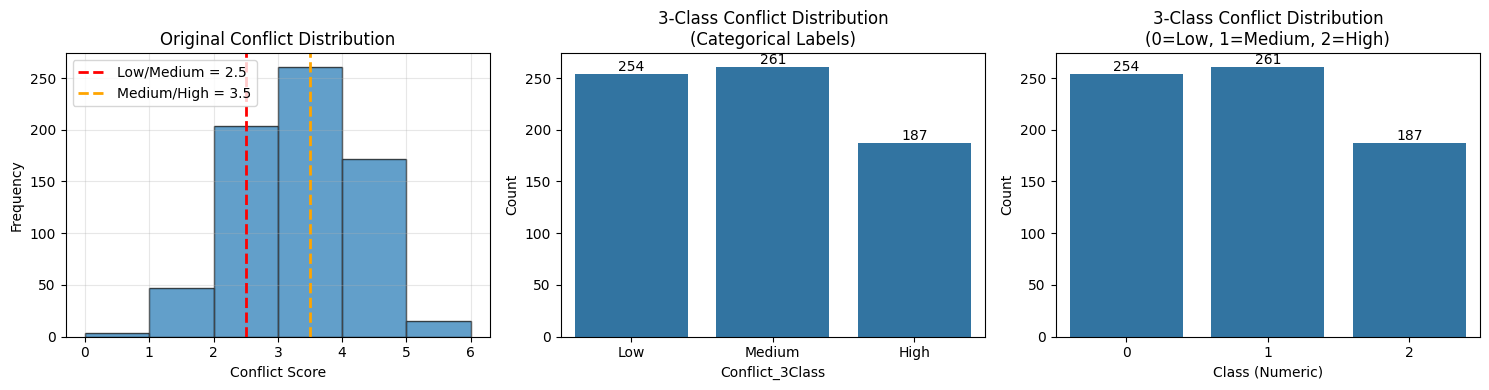

{'low_threshold': 2, 'high_threshold': 3, 'counts': {'Medium': 261, 'Low': 254, 'High': 187}, 'proportions': {'Medium': 0.3717948717948718, 'Low': 0.36182336182336183, 'High': 0.26638176638176636}, 'class_mapping': {'Low': 0, 'Medium': 1, 'High': 2}}
(702, 16)
Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Daily_Usage', 'Platform', 'Academic_Affects', 'Sleep_Hrs',
       'Mental_Health', 'Relationship_Status', 'Conflicts', 'Addicted_Score',
       'Conflict_Binary', 'Conflict_3Class', 'Conflict_3Class_Numeric'],
      dtype='object')


In [23]:
# create_multiclass_conflict
from utils import create_multiclass_conflict
df_data, results = create_multiclass_conflict(
    df_data, 
    target_column='Conflicts', 
    low_threshold=2, high_threshold=3, visualize=True)

# print the results
print(results)

# print the shape of the dataframe
print(df_data.shape)

# print the columns of the dataframe
print(df_data.columns)

In [24]:
from utils import convert_to_multiclass_target

# Convert your existing y variables to 3-class without changing X splits
y_train_3class = convert_to_multiclass_target(y_train_full, df_data, 
                                             low_threshold=2, high_threshold=3)
y_test_3class = convert_to_multiclass_target(y_test, df_data,
                                            low_threshold=2, high_threshold=3)

print("Original binary distribution:")
print(y_train_full.value_counts())
print("\nNew 3-class distribution:")  
print(y_train_3class.value_counts())

3-Class Distribution:
Low (0): 200 samples
Medium (1): 210 samples
High (2): 151 samples
3-Class Distribution:
Low (0): 54 samples
Medium (1): 51 samples
High (2): 36 samples
Original binary distribution:
Conflict_Binary
1    361
0    200
Name: count, dtype: int64

New 3-class distribution:
Conflicts
1    210
0    200
2    151
Name: count, dtype: int64


## XGBoost for multiclass classification

Running grid search for xgb_gridsearch_multiclass
Fitting 5 folds for each of 72 candidates, totalling 360 fits
f1_score: 0.98 ± 0.01
accuracy: 0.98 ± 0.01
f1_weighted: 0.98 ± 0.01
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_lambda': 1, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.98
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_lambda': 0, 'classifier__subsample': 1.0}
Best F1 score (CV): 0.9846305418719211


Registered model 'conflict_xgb_multiclass' already exists. Creating a new version of this model...
Created version '14' of model 'conflict_xgb_multiclass'.


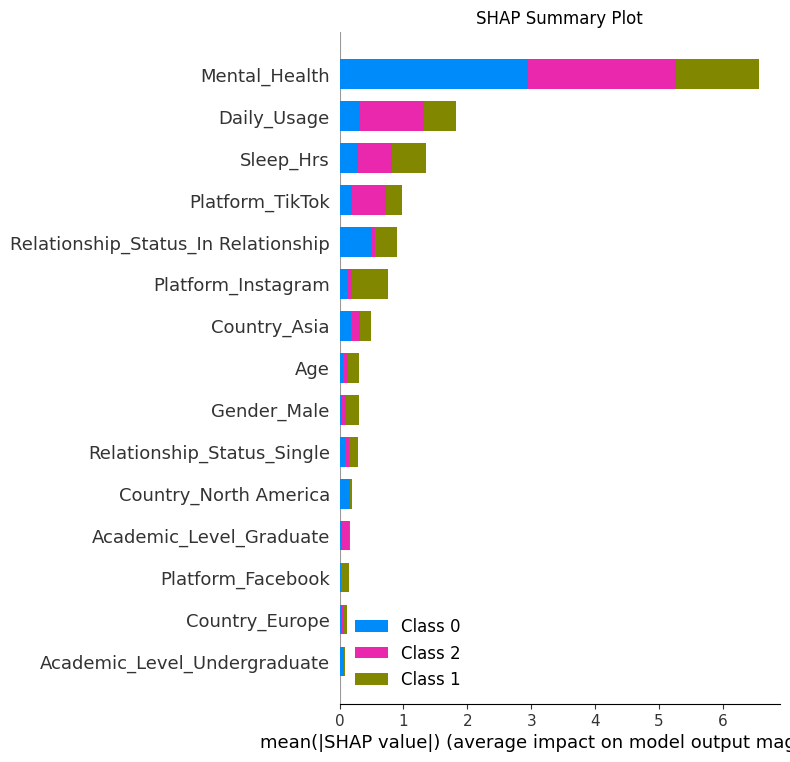

In [25]:
# apply the run_classification_gridsearch_experiment function to the 3-class target variable
# param_grid_lr['classifier__solver'] = ['lbfgs']
# from utils import run_classification_gridsearch_experiment
xgb_pipeline_multiclass = clone(xgb_pipeline)
xgb_pipeline_multiclass.set_params(
    classifier__objective='multi:softprob',  # For multiclass with probabilities
    classifier__num_class=3,                 # Number of classes (0, 1, 2)
    classifier__eval_metric='mlogloss'       # Multiclass log loss
)

multiclass_scoring = {
    "f1_score": "f1_weighted",  # for multiclass classification
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted", # for multiclass classification
}

# create the parameter grid
best_xgb_multiclass, xgb_grid_search, fig_sum, _= run_classification_gridsearch_experiment(
    name="xgb_gridsearch_multiclass",
    pipeline=xgb_pipeline,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_3class,
    X_test=X_test,
    y_test=y_test_3class,
    cv=cv,
    scoring=multiclass_scoring,
    dataset=mlflow_dataset,
    verbose = True,
    registered_model_name="conflict_xgb_multiclass",
    refit_metric="f1_weighted"  # Make sure this matches your scoring dict
)

# 3. Print summary in the output cell
print("Best parameters:", grid_search_result.best_params_)
print("Best F1 score (CV):", grid_search_result.best_score_)
fig_sum
# 4. (Optional) inspect all CV results
# cv_df = pd.DataFrame(grid_search_result.cv_results_)
# display(cv_df.sort_values("mean_test_f1_score", ascending=False).head())

## Multi-class Classificaiton without Mental Health

In [26]:
# Training xgboost with all features

# Build the full pipeline
# set the preproceesing of xgb_pipeline to preprocessor_no_mh

# Build the full pipeline
xgb_pipeline_multiclass_no_mh = clone(xgb_pipeline_multiclass)
xgb_pipeline_multiclass_no_mh.set_params(preprocessing=preprocessor_no_mh)


# create the parameter grid
best_xgb_multiclass_no_mh, xgb_grid_search_no_mh, fig_sum, _ = run_classification_gridsearch_experiment(
    name="xgb_gridsearch_multiclass_no_mh",
    pipeline=xgb_pipeline_multiclass_no_mh,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_3class,
    X_test=X_test,
    y_test=y_test_3class,
    cv=cv,
    scoring=multiclass_scoring,
    dataset=mlflow_dataset,
    verbose = True,
    registered_model_name="conflict_xgb_multiclass",
    refit_metric="f1_weighted",  # Make sure this matches your scoring dict
    feature_set="no_MH"
)

# 3. Print summary in the output cell
print("Best parameters:", grid_search_result.best_params_)
print("Best F1 score (CV):", grid_search_result.best_score_)
display(fig_sum)
# display(fig_roc)

NameError: name 'preprocessor_no_mh' is not defined

In [ ]:
catboost_pipeline_multiclass = clone(xgb_pipeline_multiclas_no)
catboost_pipeline_multiclass_no_mh.set_params(preprocessing=preprocessor_no_mh)

xgb_pipeline_multiclass_no_mh = clone(xgb_pipeline_multiclass)
xgb_pipeline_multiclass_no_mh.set_params(preprocessing=preprocessor_no_mh)


catboost_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',  # Specify multi-class classification
    eval_metric='MultiClass',
    random_seed=42,
    verbose=100
)

best_xgb_multiclass_no_mh, xgb_grid_search_no_mh, fig_sum, _ = run_classification_gridsearch_experiment(
    name="xgb_gridsearch_multiclass_no_mh",
    pipeline=xgb_pipeline_multiclass_no_mh,
    param_grid=xgb_param_grid,
    X_train=X_train_full,
    y_train=y_train_3class,
    X_test=X_test,
    y_test=y_test_3class,
    cv=cv,
    scoring=multiclass_scoring,
    dataset=mlflow_dataset,
    verbose = True,
    registered_model_name="conflict_xgb_multiclass",
    refit_metric="f1_weighted",  # Make sure this matches your scoring dict
    feature_set="no_MH"
)

